In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Phrase A
# 3.2
data = pd.read_csv(r"data.csv", encoding="latin-1")
data["CustomerID"] = data["CustomerID"].astype(dtype="Int64")
print("data head:\n", data.head())
print("\n\n")
print("data info:\n", data.info())
print("\n\n")


data head:
   InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

      InvoiceDate  UnitPrice  CustomerID         Country  
0  12/1/2010 8:26       2.55       17850  United Kingdom  
1  12/1/2010 8:26       3.39       17850  United Kingdom  
2  12/1/2010 8:26       2.75       17850  United Kingdom  
3  12/1/2010 8:26       3.39       17850  United Kingdom  
4  12/1/2010 8:26       3.39       17850  United Kingdom  



<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceN

In [3]:
# 3.9
cols = ["Country", "StockCode", "Description"]

print("Number of Unique Values:")
print(data[cols].nunique())

for col in cols:
  print(f"\n{'-' * 25}\n")
  print(data[col].value_counts(dropna=False).head())

print(f"\n{'-' * 25}\n")
print("Non-product StockCodes:")
stock_code = data["StockCode"]
# The valid StockCode begins with a 5-digit number.
is_product = data["StockCode"].astype(str).str.match(r"^\d{5}")
non_product = stock_code[~is_product]
print(non_product.value_counts().head())

Number of Unique Values:
Country          38
StockCode      4070
Description    4223
dtype: int64

-------------------------

Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Name: count, dtype: int64

-------------------------

StockCode
85123A    2313
22423     2203
85099B    2159
47566     1727
20725     1639
Name: count, dtype: int64

-------------------------

Description
WHITE HANGING HEART T-LIGHT HOLDER    2369
REGENCY CAKESTAND 3 TIER              2200
JUMBO BAG RED RETROSPOT               2159
PARTY BUNTING                         1727
LUNCH BAG RED RETROSPOT               1638
Name: count, dtype: int64

-------------------------

Non-product StockCodes:
StockCode
POST    1256
DOT      710
M        571
C2       144
D         77
Name: count, dtype: int64


In [4]:
# 3.8
cols = ["Quantity", "UnitPrice"]

print("Summary of Quantity and UnitPrice:")
print(data[cols].describe())

# Negative Quantity
print(f"\n{'-' * 25}\n")
invalid_quantity = data.loc[data["Quantity"] < 0]
print(f"Invalid quantity: {len(invalid_quantity)}")
# print(invalid_quantity.head())

# Zero/negative UnitPrice
print(f"\n{'-' * 25}\n")
invalid_price = data.loc[data["UnitPrice"] <= 0]
print(f"Invalid prices (invalid sales): {len(invalid_price)}")
print(f"\tUnitPrice == 0: {(data['UnitPrice'] == 0).sum()}")
print(f"\tUnitPrice <  0: {(data['UnitPrice'] < 0).sum()}")
# print(invalid_price.head()

Summary of Quantity and UnitPrice:
            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000

-------------------------

Invalid quantity: 10624

-------------------------

Invalid prices (invalid sales): 2517
	UnitPrice == 0: 2515
	UnitPrice <  0: 2


In [5]:
# 3.1
COUNTRY_TO_REGION = {
    # UK & Ireland
    "United Kingdom": "UK&IE",
    "EIRE": "UK&IE",  # Ireland
    "Channel Islands": "UK&IE",
    # Western Europe
    "France": "Western Europe",
    "Germany": "Western Europe",
    "Belgium": "Western Europe",
    "Netherlands": "Western Europe",
    "Austria": "Western Europe",
    "Switzerland": "Western Europe",
    # Northern Europe
    "Denmark": "Northern Europe",
    "Finland": "Northern Europe",
    "Norway": "Northern Europe",
    "Sweden": "Northern Europe",
    "Iceland": "Northern Europe",
    # Southern Europe
    "Italy": "Southern Europe",
    "Spain": "Southern Europe",
    "Portugal": "Southern Europe",
    "Greece": "Southern Europe",
    "Malta": "Southern Europe",
    "Cyprus": "Southern Europe",
    # Eastern Europe
    "Poland": "Eastern Europe",
    "Czech Republic": "Eastern Europe",
    "Lithuania": "Eastern Europe",
    # North America
    "USA": "North America",
    "Canada": "North America",
    # Middle East
    "Bahrain": "Middle East",
    "Israel": "Middle East",
    "Lebanon": "Middle East",
    "Saudi Arabia": "Middle East",
    "United Arab Emirates": "Middle East",
    # Asia-Pacific
    "Hong Kong": "Asia-Pacific",
    "Japan": "Asia-Pacific",
    "Singapore": "Asia-Pacific",
    "Australia": "Asia-Pacific",
    # Other
    "Brazil": "South America",
    "RSA": "Africa",  # South Africa
    "European Community": "Unknown",
    "Unspecified": "Unknown",
}

# Check
for ct in data["Country"].unique():
    if ct not in COUNTRY_TO_REGION:
        print(f"Country '{ct}' is not in the mapping dictionary.")
else:
    print("All countries are accounted for in the mapping dictionary.")


All countries are accounted for in the mapping dictionary.


In [6]:
# Phase B
# 3.3
# print(data.iloc[0:5, 0:3])

# Create a unique line-item index for the DataFrame (format: "L000000", "L000001", etc.)
data_num = len(data)
data.index = pd.Index([f"L{i:06d}" for i in range(data_num)], name="line_item")
# print(data.loc["L000005"])
data

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
line_item,,,,,,,,
L000000,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850,United Kingdom
L000001,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850,United Kingdom
L000002,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850,United Kingdom
L000003,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850,United Kingdom
L000004,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850,United Kingdom
...,...,...,...,...,...,...,...,...
L541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680,France
L541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680,France
L541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680,France


In [7]:
# 3.4
is_cancelled = data["InvoiceNo"].astype(str).str.startswith("C")
bad_qty = data["Quantity"] <= 0
bad_price = data["UnitPrice"] <= 0

print(f"Number of canceled orders: {is_cancelled.sum()}")
print(f"Number of orders with non-positive quantity: {bad_qty.sum()}")
print(f"Number of orders with non-positive unit price: {bad_price.sum()}")

Number of canceled orders: 9288
Number of orders with non-positive quantity: 10624
Number of orders with non-positive unit price: 2517


In [8]:
# 3.5
data["Revenue"] = data["Quantity"] * data["UnitPrice"]
data["Revenue"] = data["Revenue"].round(3)
cols = ["InvoiceNo", "Quantity", "UnitPrice", "Revenue"]
print("Top largest bulk orders:")
print(data.sort_values("Quantity", ascending=False)[cols].head())
print("\nTop largest returns:")
print(data.sort_values("Revenue", ascending=True)[cols].head())

Top largest bulk orders:
          InvoiceNo  Quantity  UnitPrice   Revenue
line_item                                         
L540421      581483     80995       2.08  168469.6
L061619      541431     74215       1.04   77183.6
L502122      578841     12540       0.00       0.0
L074614      542504      5568       0.00       0.0
L421632      573008      4800       0.21    1008.0

Top largest returns:
          InvoiceNo  Quantity  UnitPrice    Revenue
line_item                                          
L540422     C581484    -80995       2.08 -168469.60
L061624     C541433    -74215       1.04  -77183.60
L222681     C556445        -1   38970.00  -38970.00
L524602     C580605        -1   17836.46  -17836.46
L043702     C540117        -1   16888.02  -16888.02


In [9]:
# Phase C
# 3.6
data["Country"] = data["Country"].replace({ "EIRE": "Ireland", "RSA": "South Africa", "Unspecified": pd.NA })  # type: ignore
print("EIRE -> Ireland, RSA -> South Africa, Unspecified -> missing")
print(data["Country"].value_counts(dropna=False).head())

EIRE -> Ireland, RSA -> South Africa, Unspecified -> missing
Country
United Kingdom    495478
Germany             9495
France              8557
Ireland             8196
Spain               2533
Name: count, dtype: int64


In [10]:
# 3.7
COLUMN_MAP={
    "InvoiceNo": "invoice_no", "StockCode": "stock_code",
    "Description": "description", "Quantity": "quantity",
    "InvoiceDate": "invoice_date", "UnitPrice": "unit_price",
    "CustomerID": "customer_id", "Country": "country",
}
data.rename(columns=COLUMN_MAP, inplace=True)
print(data.columns)


Index(['invoice_no', 'stock_code', 'description', 'quantity', 'invoice_date',
       'unit_price', 'customer_id', 'country', 'Revenue'],
      dtype='str')


In [11]:
# 3.10
# Custom ID
print("Number of missing customer IDs:", data["customer_id"].isnull().sum())
data["customer_id"] = data["customer_id"].fillna(-1)
# Empty descriptions
# mask = data["description"].str.strip().eq("")
print("Number of empty descriptions:", data["description"].isnull().sum())
data["description"] = data["description"].fillna(pd.NA)


Number of missing customer IDs: 135080
Number of empty descriptions: 1454


In [12]:
# 3.11
# [TODO]?


In [13]:
# 3.12
# is_cancelled bad_price bad_qty
print(f"Data size before dropping invalid rows: {len(data)}")
data = data.drop(index=data[is_cancelled | bad_price | bad_qty].index)
not_product = (~data["stock_code"].astype(str).str.match(r"^\d{5}"))
data = data.drop(index=data[not_product].index)
data = data.dropna(subset=["description"])
print(f"Data size after dropping invalid rows: {len(data)}")

Data size before dropping invalid rows: 541909
Data size after dropping invalid rows: 527725


In [14]:
# 3.13
duplicate_number = int(data.duplicated().sum())
data = data.drop_duplicates().reset_index(drop=True)
print("Exact duplicate rows removed:", duplicate_number)
print("Rows remaining:", len(data))

Exact duplicate rows removed: 5221
Rows remaining: 522504


In [15]:
# Phase D
# 3.18
data.rename(columns={"Revenue": "revenue"}, inplace=True)
# data.columns

data["description"] = data["description"].apply(lambda s: str(s).strip().title())
data["is_cancelled"] = data["invoice_no"].astype(str).str.startswith("C")

data.head()

,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,revenue,is_cancelled
0,536365,85123A,White Hanging Heart T-Light Holder,6,12/1/2010 8:26,2.55,17850,United Kingdom,15.30,False
1,536365,71053,White Metal Lantern,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,False
2,536365,84406B,Cream Cupid Hearts Coat Hanger,8,12/1/2010 8:26,2.75,17850,United Kingdom,22.00,False
3,536365,84029G,Knitted Union Flag Hot Water Bottle,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,False
4,536365,84029E,Red Woolly Hottie White Heart.,6,12/1/2010 8:26,3.39,17850,United Kingdom,20.34,False


In [16]:
# 3.17
# [TODO]

In [17]:
# 3.14
rev_by_country = data.groupby("country")["revenue"].sum().sort_values(ascending=False)
print("Revenue by country:", rev_by_country.head(), sep="\n")

print(f"\n{'-' * 25}\n")

orders_per_customer = data[data["customer_id"] != -1].groupby("customer_id")["invoice_no"].nunique().sort_values(ascending=False)
print("Orders per customer:", orders_per_customer.head(), sep="\n")

Revenue by country:
country
United Kingdom    8724045.22
Netherlands        283889.34
Ireland            270850.86
Germany            205381.15
France             184493.00
Name: revenue, dtype: float64

-------------------------

Orders per customer:
customer_id
12748    206
14911    198
17841    124
13089     97
15311     91
Name: invoice_no, dtype: int64


In [18]:
# 3.16
by_country = data.groupby("country").agg(
    total_revenue=("revenue", "sum"),
    mean_line_value=("revenue", "mean"),
    transactions=("invoice_no", "nunique"),
).sort_values("total_revenue", ascending=False)
# by_country.head()

mask = data["customer_id"] != -1
by_customer = data[mask].groupby("customer_id").agg(
    total_revenue=("revenue", "sum"),
    mean_line_value=("revenue", "mean"),
    transactions=("invoice_no", "nunique"),
).sort_values("transactions", ascending=False)
by_customer.head()

,total_revenue,mean_line_value,transactions
customer_id,,,
12748,31650.78,7.198267,206
14911,136161.83,24.384282,198
17841,40495.99,5.281856,124
13089,58762.08,32.393649,97
15311,60632.75,25.626691,91


In [19]:
# 3.19
data["invoice_date"] = pd.to_datetime(data["invoice_date"])  # Also for 3.15

valid_customers = data[data["customer_id"] != -1]

def customer_summary(cs):
    return pd.Series({
        "total_spend":   cs["revenue"].sum(),
        "n_orders":      cs["invoice_no"].nunique(),
        "active_months": cs["invoice_date"].dt.to_period("M").nunique(),
    })

per_customer = valid_customers.groupby("customer_id").apply(customer_summary)
per_customer["n_orders"] = per_customer["n_orders"].astype(int)
per_customer["active_months"] = per_customer["active_months"].astype(int)
per_customer.sort_values("n_orders", ascending=False).head()


,total_spend,n_orders,active_months
customer_id,,,
12748,31650.78,206,13
14911,136161.83,198,13
17841,40495.99,124,13
13089,58762.08,97,13
15311,60632.75,91,13


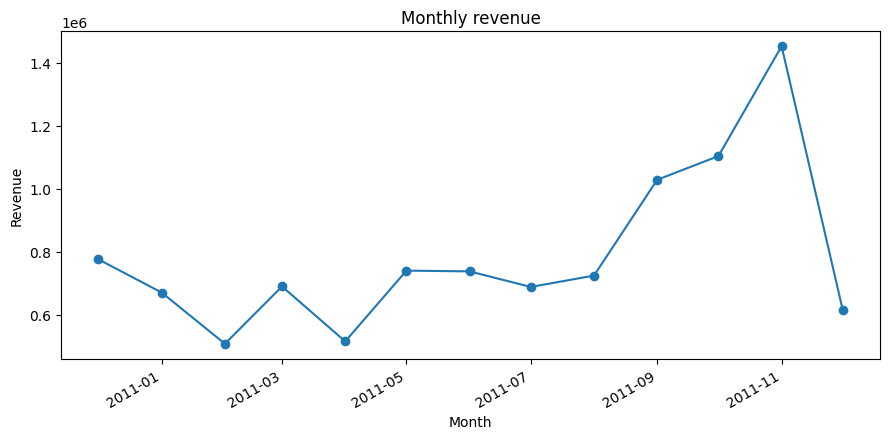

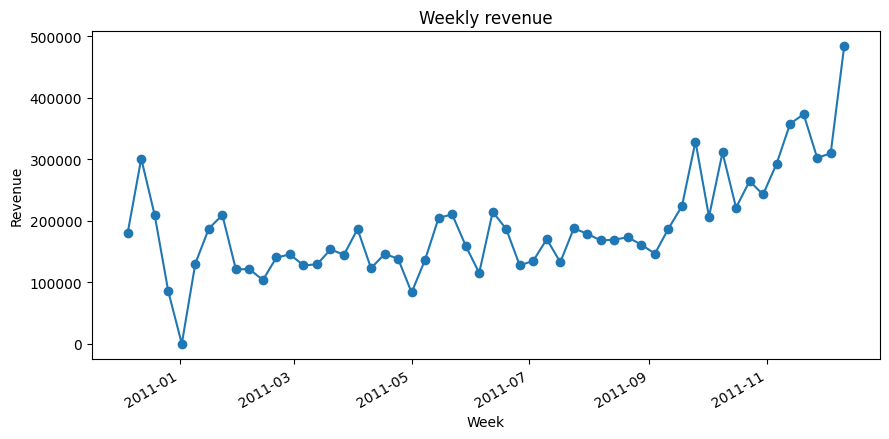

In [20]:
# 3.15
ts = data.set_index("invoice_date").sort_index()

# Monthly
monthly = ts["revenue"].resample("MS").sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly.index, monthly.values, marker="o")
ax.set_title("Monthly revenue"); ax.set_xlabel("Month"); ax.set_ylabel("Revenue")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(r"monthly_revenue.png")

# Weekly
weekly = ts["revenue"].resample("W").sum()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(weekly.index, weekly.values, marker="o")
ax.set_title("Weekly revenue"); ax.set_xlabel("Week"); ax.set_ylabel("Revenue")
fig.autofmt_xdate(); fig.tight_layout()
fig.savefig(r"weekly_revenue.png")
plt.show()

In [21]:
# 3.20

In [22]:
# 3.21

In [ ]:
data.to_csv(r"cleaned_online_retail.csv", index=False)
data.dtypes

invoice_no                 str
stock_code                 str
description                str
quantity                 int64
invoice_date    datetime64[us]
unit_price             float64
customer_id              Int64
country                    str
revenue                float64
is_cancelled              bool
dtype: object